$$
\mathcal{L}_{\text{std}}
=
\frac{1}{D}
\sum_{d=1}^{D}
\operatorname{ReLU}
\left(
1 -
\sqrt{\operatorname{Var}(x_{\cdot d}) + 0.0001}
\right)
$$

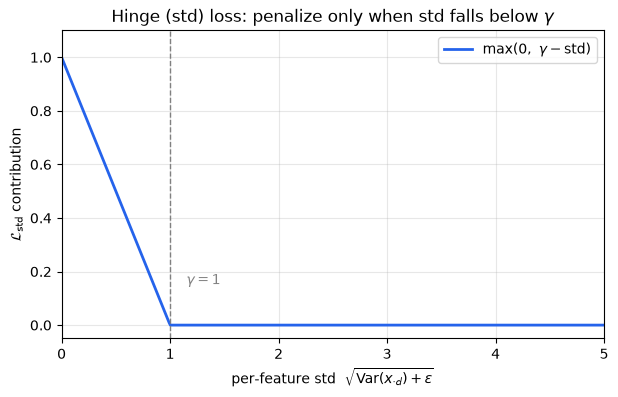

In [1]:
import numpy as np
import matplotlib.pyplot as plt

gamma = 1.0
# x-axis: per-feature std = sqrt(Var + eps)
std = np.linspace(0, 5, 500)
loss = np.maximum(0.0, gamma - std)  # hinge / ReLU

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(std, loss, color="#2563eb", lw=2, label=r"$\max(0,\ \gamma - \mathrm{std})$")

# mark the hinge point at std = gamma
ax.axvline(gamma, color="gray", ls="--", lw=1)
ax.annotate(r"$\gamma=1$", xy=(gamma, 0), xytext=(gamma + 0.15, 0.15), color="gray")

ax.set_xlim(0, 5)
ax.set_ylim(-0.05, 1.1)
ax.set_xlabel(r"per-feature std  $\sqrt{\mathrm{Var}(x_{\cdot d}) + \epsilon}$")
ax.set_ylabel(r"$\mathcal{L}_{\mathrm{std}}$ contribution")
ax.set_title("Hinge (std) loss: penalize only when std falls below $\\gamma$")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [1]:
import sys, os
# --- project bootstrap ---------------------------------------------------
# This notebook lives under notebooks/<pre|post>_training/, but it imports the
# my_image_jepa modules (dataset, model, eval, losses, lars, scheduler) and
# reads paths relative to the my_image_jepa root (./data, ./checkpoints, cfgs/).
# Walk up to that root (the dir holding main.py + cfgs/) and make it both the
# working directory and an import root, so the notebook runs from anywhere.
from pathlib import Path

ROOT = Path.cwd()
while not ((ROOT / "main.py").exists() and (ROOT / "cfgs").is_dir()) and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(f"project root: {ROOT}")

project root: /Users/hawardizayee/Desktop/AMI/eb_jepa/examples/my_image_jepa


In [ ]:
import torch

artifact_dir = '/Users/hawardizayee/Desktop/AMI/eb_jepa/examples/my_image_jepa/artifacts/image_jepa_checkpoint:v0'
ckpt = torch.load(f"{artifact_dir}/latest.pth.tar", map_location="cpu")

In [17]:
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


from dataset import get_train_transforms

base_train_dataset = CIFAR10(
        root= "./data", train=True, download=False, 
    )

from dataset import ImageDataset

train_transform = get_train_transforms()
train_dataset = ImageDataset(base_train_dataset,train_transform,2)
train_loader = DataLoader(train_dataset,batch_size=10,shuffle=False)

from model import ResNet18, ImageSSL

backbone = ResNet18()

model = ImageSSL(
    backbone= backbone,
    features_dim= backbone.features_dim
)

model.load_state_dict(ckpt["model_state_dict"])

<All keys matched successfully>

In [18]:
model.eval()
with torch.no_grad():
    for batch in train_loader:
        (view0,view1),label = batch
        features_1, z1 = model(view0)
        features_2, z2 = model(view1)
        break

In [19]:
z1.shape

torch.Size([10, 2048])

In [20]:
z1[:, 0].std()

tensor(0.8801)

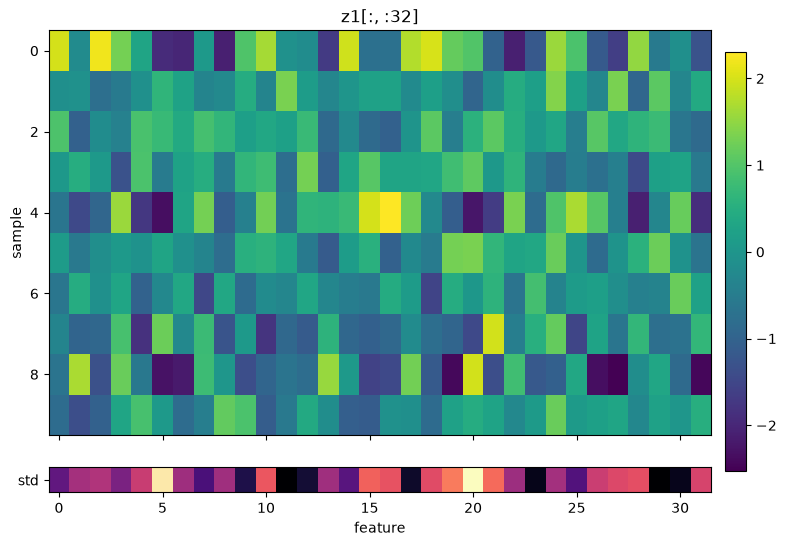

In [21]:
import numpy as np

# first 32 features of z1 -> (32 samples, 32 features)
z = z1[:, :32].detach().cpu().numpy()
std = z.std(axis=0)  # per-feature std across the batch

fig, (ax_map, ax_std) = plt.subplots(
    2, 1, figsize=(9, 6),
    gridspec_kw={"height_ratios": [16, 1], "hspace": 0.15},
    sharex=True,
)

# heatmap: rows = samples, cols = features
im = ax_map.imshow(z, aspect="auto", cmap="viridis")
ax_map.set_ylabel("sample")
ax_map.set_title("z1[:, :32]")
fig.colorbar(im, ax=[ax_map, ax_std], fraction=0.03, pad=0.02)

# thin std bar aligned under each feature column
ax_std.imshow(std[None, :], aspect="auto", cmap="magma")
ax_std.set_yticks([0])
ax_std.set_yticklabels(["std"])
ax_std.set_xlabel("feature")

plt.show()